In [200]:
import pandas as pd
from sklearn.linear_model import Ridge,Lasso,ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from typing import Literal
import matplotlib.pyplot as plt
from mlxtend.evaluate import bias_variance_decomp

In [201]:
df = pd.read_csv("C://Users//Acer//OneDrive//Desktop//Datasets//Real_estate.csv")
df.drop(columns=['No'],inplace=True)
df.columns = ['date','house age','distance_mrt','stores','latitude','longitude','price_unit']
df.sample(5)

,date,house age,distance_mrt,stores,latitude,longitude,price_unit
115,2013.083,20.6,737.9161,2,24.98092,121.54739,46.4
279,2013.417,2.6,1554.2500,3,24.97026,121.51642,31.1
157,2013.250,16.1,815.9314,4,24.97886,121.53464,35.6
85,2012.750,0.0,338.9679,9,24.96853,121.54413,50.8
223,2013.250,9.1,1402.0160,0,24.98569,121.52760,42.3


In [202]:
x = df.drop(columns=['price_unit'])
y = df['price_unit']

In [203]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [204]:
scale = StandardScaler()
x_train = scale.fit_transform(x_train)
x_test = scale.transform(x_test)

In [205]:
def fit_model(model : Literal['L','E','R'],x_train,y_train,x_test,y_test,alpha,epochs,l1_ratio=None):
    
    if model=='L':
        lasso = Lasso(alpha=alpha,max_iter=epochs,random_state=42)
        lasso.fit(x_train,y_train)
        y_pred = lasso.predict(x_test)
        x_train_pred = lasso.predict(x_train)
        r2 = r2_score(y_test,y_pred)

    if model=='E':
        elas = ElasticNet(alpha=alpha,l1_ratio=l1_ratio,max_iter=epochs,random_state=42)
        elas.fit(x_train,y_train)
        y_pred = elas.predict(x_test)
        x_train_pred = elas.predict(x_train)
        r2 = r2_score(y_test,y_pred)

    if model=='R':
        ridge = Ridge(alpha=alpha,max_iter=epochs,random_state=42)
        ridge.fit(x_train,y_train)
        y_pred = ridge.predict(x_test)
        x_train_pred = ridge.predict(x_train)
        r2 = r2_score(y_test,y_pred)
        
    return r2,x_train_pred

In [206]:
r2,x_train_pred = fit_model(model='E',x_train=x_train,y_train=y_train,x_test=x_test,y_test=y_test,alpha=0.1,epochs=100,l1_ratio=0.11)
print(r2)

0.6849382154079224


In [207]:
'''
with ridge regression , model is optimised at alpha=25 for 100 epochs - i.e 0.6849 r2 score.
with lasso regression , model is optimised at alpha=0.205 for 100 epochs - i.e 0.6839 r2 score.
with elasticnet regression , model is optimised at alpha = 0.1 and l1_ratio = 0.11 - i.e 0.68495 r2 score.

'''

'\nwith ridge regression , model is optimised at alpha=25 for 100 epochs - i.e 0.6849 r2 score.\nwith lasso regression , model is optimised at alpha=0.205 for 100 epochs - i.e 0.6839 r2 score.\nwith elasticnet regression , model is optimised at alpha = 0.1 and l1_ratio = 0.11 - i.e 0.68495 r2 score.\n\n'

In [209]:
df2 = pd.read_csv("C://Users//Acer//OneDrive//Desktop//Datasets//Salary_dataset.csv")
df2.sample(6)
x = df2['YearsExperience']
y = df2['Salary']

x_train2,x_test2,y_train2,y_test2 = train_test_split(x,y,test_size=0.2,random_state=42)


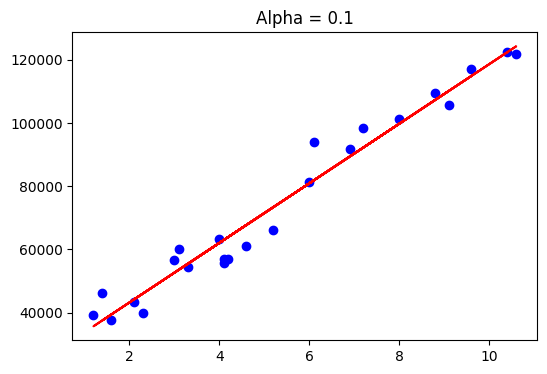

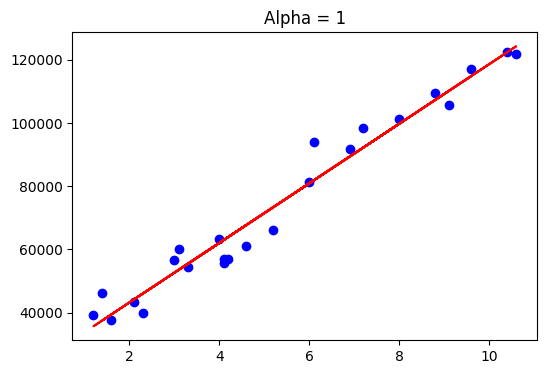

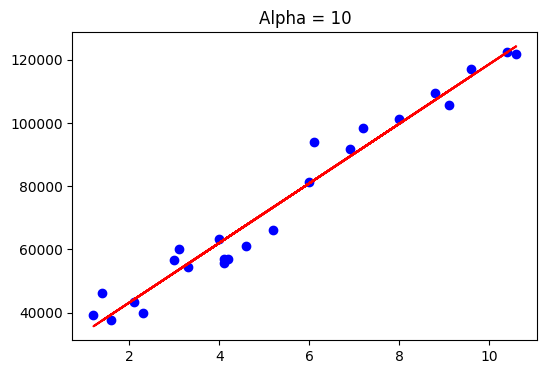

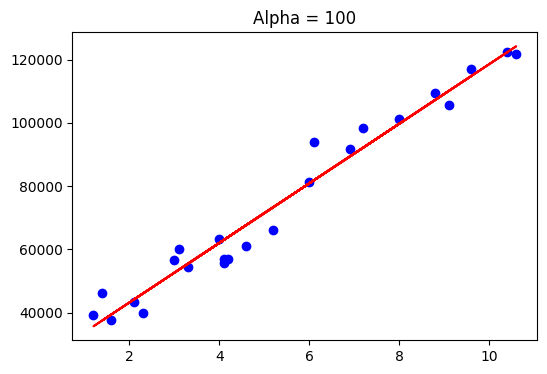

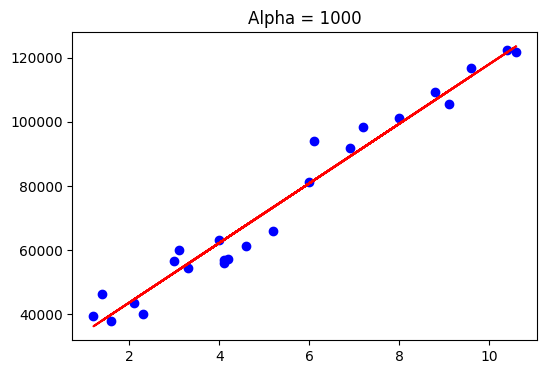

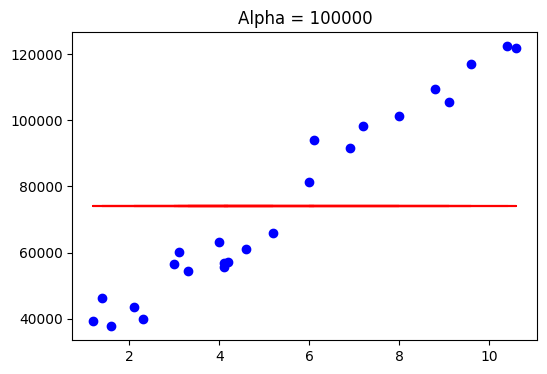

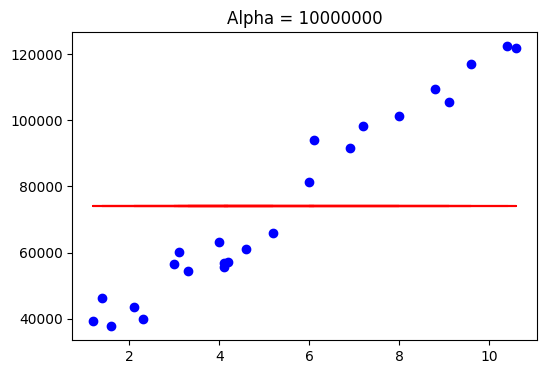

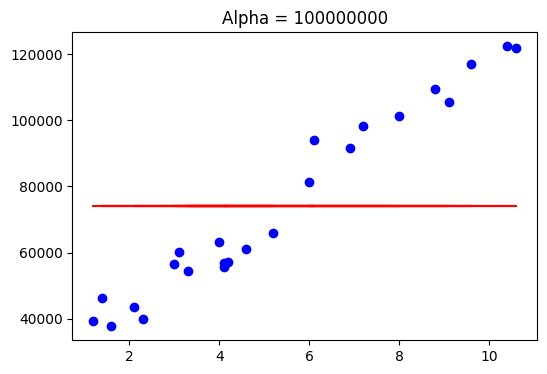

In [210]:
for alpha in [0.1,1,10,100,1000,100000,10000000,100000000]:
    

    x_train2_df = x_train2.to_frame()
    lasso = Lasso(alpha=alpha)
    lasso.fit(x_train2_df, y_train2)
    
    plt.figure(figsize=(6,4))
    plt.scatter(x_train2_df, y_train2, color='b')
    plt.plot(x_train2_df,lasso.predict(x_train2_df),color='r')
    plt.title(f'Alpha = {alpha}')

    